# Data Cleaning and Pre-Processing: Sentiment140 Datensatz

## Data Cleaning and Preparation

<img src="Bilder/dslc-data-cleaning-and-preparation.png" width="800" />

### Text-Bereinigung (Data Cleaning)

Schritte:

- Analog zum Paper werden Nennungen von Nutzern _@<user-name>_, nicht alpha-numerische Worte und URLs entfernt (s. RegEx in __sanitize_tweets_ im [preprocessing](data/preprocessing.py) Modul).
- Tag-Zeichen _#_ werden entfernt.
- Zahlen werden entfernt.
- Zeichen, die nicht alpha-numerisch sind, werden entfernt. Apostrophe bleiben jedoch als Ausnahme erhalten.
- Wiederholungen von Buchstaben (bspw. _huuuuungryyyy_) werden so modifiziert, dass maximal 2 gleiche Buchstaben aufeinander folgen.
- Der Text wird in Kleinschreibung umgewandelt.

**Hinweis**: Kontraktionen (wie _aren't_ für _are not_) werden _nicht_ entfernt, da diese typisch für Tweets sind. Um diese Wortformen korrekt zu verarbeiten wird ein spezifischer Tokenizer verwendet (s.u.).

In [1]:
import pandas as pd

from propra_webscience_ws24.data import preprocessing
from propra_webscience_ws24.constants import TRAIN_DATASET_FILE_PATH


pd.options.display.max_colwidth = None


df_train = pd.read_parquet(TRAIN_DATASET_FILE_PATH)
for sample in df_train.head(5).itertuples():
    print(f"{sample.text!r} \n=> {preprocessing._sanitize_tweets(sample.text)!r}\n")

"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D" 
=> "a that's a bummer  you shoulda got david carr of third day to do it d"

"is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!" 
=> "is upset that he can't update his facebook by texting it and might cry as a result  school today also blah"

'@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds' 
=> 'i dived many times for the ball managed to save  the rest go out of bounds'

'my whole body feels itchy and like its on fire ' 
=> 'my whole body feels itchy and like its on fire'

"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. " 
=> "no it's not behaving at all i'm mad why am i here because i can't see you all over there"



### Aufbereitung der Daten (Data Preparation)

Schritte:

- Für jeden bereinigten Tweets werden die jeweiligen Token mittels **TweetTokenizer** ermittelt. Diese Tokenizer verarbeitet informelle und unstrukturierte Texte besser als andere Tokenizer.
- Die Token werden mittels Lemmatizer/Stemmer normalisiert.
- Es werden die folgenden Lemmatizer und Stemmer verwendet:
    - WordNetLemmatizer
    - PorterStemmer
    - LancasterStemmer
- Zusätzlich wird eine Variante verwendet, bei der die Token nicht normalisiert werden.
- Für jeden der Lemmatizer/Stemmer werden eigene Ausgabedateien (unter `datasets/sentiment140/processed_tweets`) erzeugt, die im Trainingsschritt verwendet werden können. Je Lemmatizer/Stemmer werden separate Ausgabedateien für die Trainings- und die Testdaten erzeugt.
- Für weitere Analysen werden zwei Ausgaben mit/ohne Entfernung der Stoppwörter erzeugt.

#### Entfernung von Stopp-Wörtern

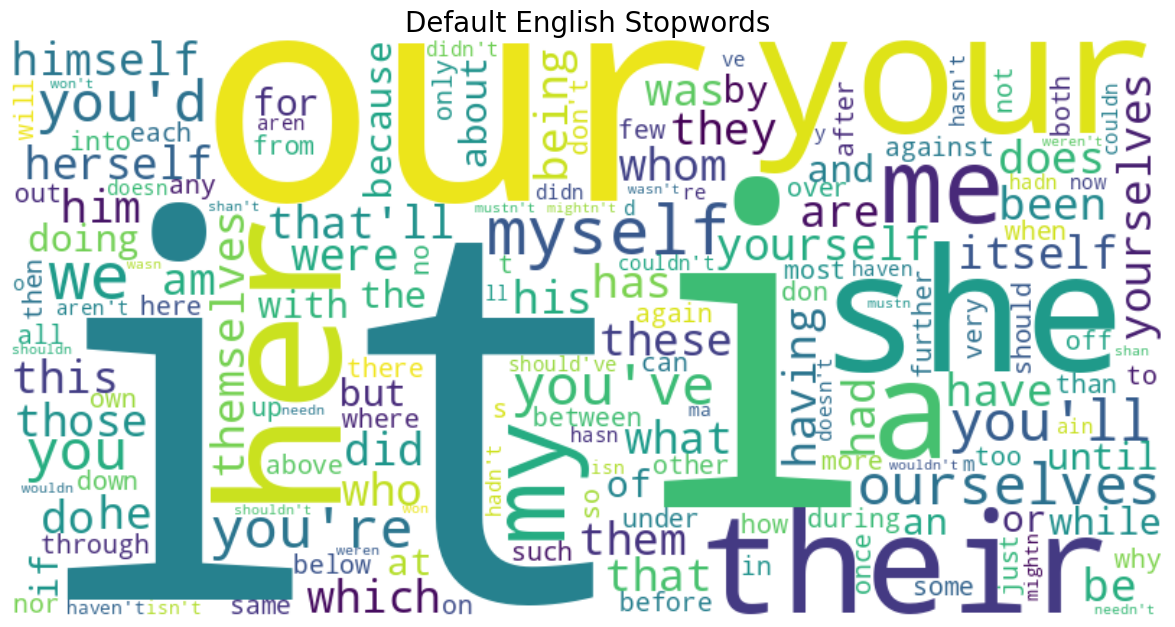

In [2]:
from nltk.corpus import stopwords
from wordcloud import WordCloud
from matplotlib import pyplot as plt

default_english_stopwords = stopwords.words('english')
txt=' '.join(default_english_stopwords)

def plot_wordcloud(txt, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        collocations=False,
        stopwords=["n't", "d've" "u're", "u'll", "u'd"]
    ).generate(txt)

    plt.figure(figsize=(15, 7.5))
    plt.title(title, fontsize=20)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

plot_wordcloud(txt, 'Default English Stopwords')

##### Verwendung einer modifizierten Stoppwort-Liste

Weil viele der Stoppwörter Negationen (wie _not_) oder Kontraktionen enthalten würde die semantische Bedeutung der Tweets durch eine Anwendung der standard-Stoppwortliste in einigen Fällen komplett verändert.

Deshalb wird eine modifizierte Stoppwort-Liste verwendet, bei der Negationen und Kontraktionen aus der ursprünglichen Stopwortliste entfernt werden (s. [`_get_custom_stopwords` im preprocessing Modul](data/preprocessing.py)).

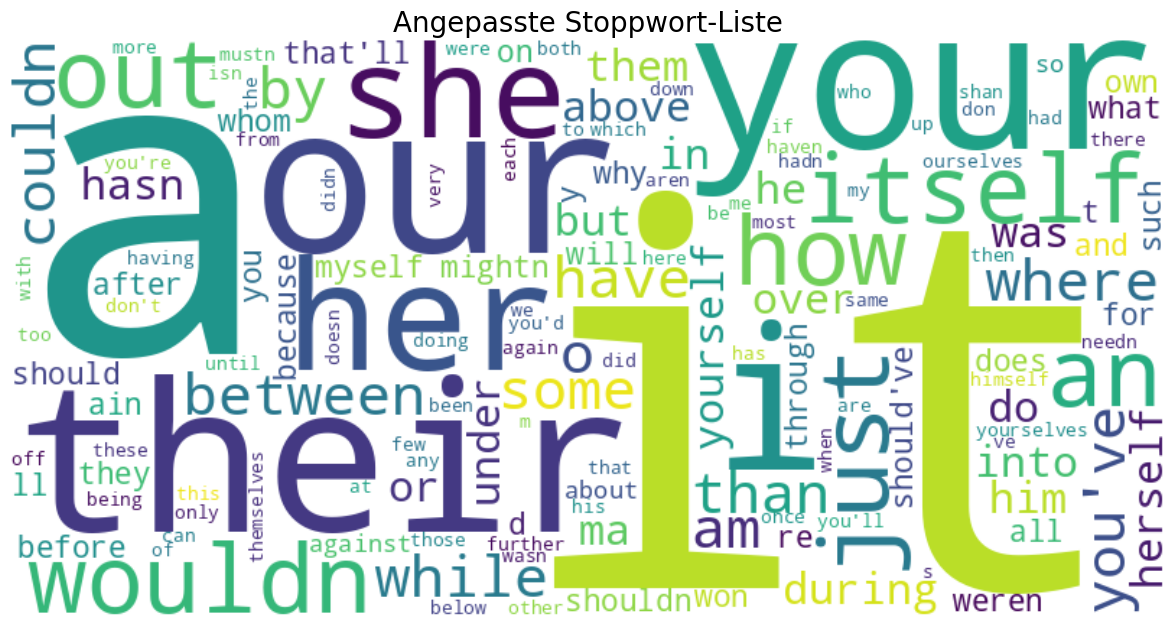

In [3]:
custom_stopwords = preprocessing._get_custom_stopwords()
txt = ' '.join(custom_stopwords)
plot_wordcloud(txt, 'Angepasste Stoppwort-Liste')

In [4]:
for sample in df_train.head(5).itertuples():
    print(f"[originaler Tweet] {sample.text!r}") 

    sanitized_txt =  preprocessing._sanitize_tweets(sample.text)

    tweet_with_stopwords = preprocessing._normalize_text(sanitized_txt, False, preprocessing.TextNormalizationStrategy.NONE)
    print(f"[bereinigter Tweet mit Stoppwörtern] {tweet_with_stopwords!r}")
    tweet_without_stopwords = preprocessing._normalize_text(sanitized_txt, True, preprocessing.TextNormalizationStrategy.NONE)
    print(f"[bereinigter Tweet ohne Stoppwörter] {tweet_without_stopwords!r}\n")

[originaler Tweet] "@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"
[bereinigter Tweet mit Stoppwörtern] "a that's a bummer you shoulda got david carr of third day to do it d"
[bereinigter Tweet ohne Stoppwörter] "that's bummer shoulda got david carr third day"

[originaler Tweet] "is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!"
[bereinigter Tweet mit Stoppwörtern] "is upset that he can't update his facebook by texting it and might cry as a result school today also blah"
[bereinigter Tweet ohne Stoppwörter] "upset can't update facebook texting might cry result school today also blah"

[originaler Tweet] '@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds'
[bereinigter Tweet mit Stoppwörtern] 'i dived many times for the ball managed to save the rest go out of bounds'
[bereinigter Tweet ohne Stoppwörter] 'dived many t

#### Wort-Normalisierung: Unterschiedliche Lemmatizer/Stemmer

In [5]:
df_train_cleaned, df_test_cleaned = preprocessing.get_cleaned_tweets()

def get_first_n_pre_processed_tweets(df, normalization_strategy, n=5):
    df_subset = df.head(n)
    print(f"Normalisierungsstrategie: {normalization_strategy.name}")
    return preprocessing._preprocess_tweets(
        df=df_subset,
        remove_stopwords=False,
        normalization_strategy=normalization_strategy,
    )
    

# WordNetLemmatizer
get_first_n_pre_processed_tweets(df_train_cleaned, preprocessing.TextNormalizationStrategy.LEMMATIZER)

Normalisierungsstrategie: LEMMATIZER


,sentiment,text,cleaned_text,processed_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",a that's a bummer you shoulda got david carr of third day to do it d,a that's a bummer you shoulda got david carr of third day to do it d
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,is upset that he can't update his facebook by texting it and might cry a a result school today also blah
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,i dived many times for the ball managed to save the rest go out of bounds,i dived many time for the ball managed to save the rest go out of bound
3,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,my whole body feel itchy and like it on fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",no it's not behaving at all i'm mad why am i here because i can't see you all over there,no it's not behaving at all i'm mad why am i here because i can't see you all over there


In [6]:
# PorterStemmer
get_first_n_pre_processed_tweets(df_train_cleaned, preprocessing.TextNormalizationStrategy.PORTER)

Normalisierungsstrategie: PORTER


,sentiment,text,cleaned_text,processed_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",a that's a bummer you shoulda got david carr of third day to do it d,a that' a bummer you shoulda got david carr of third day to do it d
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,is upset that he can't updat hi facebook by text it and might cri as a result school today also blah
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,i dived many times for the ball managed to save the rest go out of bounds,i dive mani time for the ball manag to save the rest go out of bound
3,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,my whole bodi feel itchi and like it on fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",no it's not behaving at all i'm mad why am i here because i can't see you all over there,no it' not behav at all i'm mad whi am i here becaus i can't see you all over there


In [7]:

# LancasterStemmer
get_first_n_pre_processed_tweets(df_train_cleaned, preprocessing.TextNormalizationStrategy.LANCASTER)


Normalisierungsstrategie: LANCASTER


,sentiment,text,cleaned_text,processed_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",a that's a bummer you shoulda got david carr of third day to do it d,a that's a bum you should got david car of third day to do it d
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,is upset that he can't upd his facebook by text it and might cry as a result school today also blah
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,i dived many times for the ball managed to save the rest go out of bounds,i div many tim for the bal man to sav the rest go out of bound
3,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,my whol body feel itchy and lik it on fir
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",no it's not behaving at all i'm mad why am i here because i can't see you all over there,no it's not behav at al i'm mad why am i her becaus i can't see you al ov ther


## Speicherung der bereinigten Datensätze

In [ ]:
# Hinweis: Dieser Codeblock kann einige Minuten dauern, weil alle 
# Normalisierungs- und Stoppwort Kombinationen (in mehreren Prozessen) durchlaufen werden!
!python -m propra_webscience_ws24.data.preprocessing

Skipping data processing as output file already exists: datasets/sentiment140/processed_tweets/train-tweets-lemmatizer-wo-stopwords.parquet
Skipping data processing as output file already exists: datasets/sentiment140/processed_tweets/test-tweets-lemmatizer-wo-stopwords.parquet
Skipping data processing as output file already exists: datasets/sentiment140/processed_tweets/train-tweets-lemmatizer-w-stopwords.parquet
Skipping data processing as output file already exists: datasets/sentiment140/processed_tweets/test-tweets-lemmatizer-w-stopwords.parquet
Skipping data processing as output file already exists: datasets/sentiment140/processed_tweets/train-tweets-porter-wo-stopwords.parquet
Skipping data processing as output file already exists: datasets/sentiment140/processed_tweets/test-tweets-porter-wo-stopwords.parquet
Skipping data processing as output file already exists: datasets/sentiment140/processed_tweets/train-tweets-porter-w-stopwords.parquet
Skipping data processing as output fil